# Week 7 · Day 1 — Practice Lab: Charting the Gapminder Data

In class you learned line, bar, scatter, and histogram plots, and how Seaborn
makes them prettier. Now it is your turn.

Work through each task. Try it yourself first, then run your cell to check.
Every chart you make should have a **title**, an **x-label**, and a **y-label**.

Run the setup cell below first.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../Day1/data/gapminder.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (1704, 6)


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


> **Note on the data path:** if the line above gives a *file not found* error, change the path to wherever your `gapminder.csv` is saved. In Google Colab, upload the file and use `"gapminder.csv"`.

## Task 1 — A line plot for one country

Pick **India**. Filter the data to India, then draw a line plot of `year` (x) vs
`lifeExp` (y). Add a title and axis labels.

*Hint:* `india = df[df["country"] == "India"]`

In [3]:
# Your code here
ind = df[df["country"] == "India"]
print(ind[["year", "lifeExp"]].to_string(index=False))


 year  lifeExp
 1952   37.373
 1957   40.249
 1962   43.605
 1967   47.193
 1972   50.651
 1977   54.208
 1982   56.596
 1987   58.553
 1992   60.223
 1997   61.765
 2002   62.879
 2007   64.698


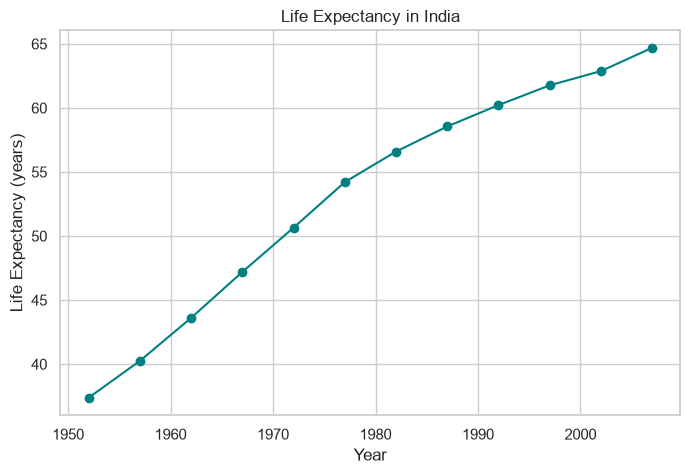

In [6]:
plt.figure(figsize=(8, 5))          # width, height in inches
plt.plot(ind["year"], ind["lifeExp"], marker="o", color="teal")

plt.title("Life Expectancy in India")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.show()

## Task 2 — A bar plot comparing continents

Filter the data to the year **1952**. Group by `continent` and take the mean of
`pop`... actually let's compare `lifeExp`. Make a bar plot of average life
expectancy per continent in 1952.

Compare it later with the 2007 chart from class — the whole world improved.

In [10]:
# Your code here

df_1952 = df[df["year"] == 1952]

continent = df_1952.groupby("continent")["lifeExp"].mean()
print(continent.round(1))

continent
Africa      39.1
Americas    53.3
Asia        46.3
Europe      64.4
Oceania     69.3
Name: lifeExp, dtype: float64


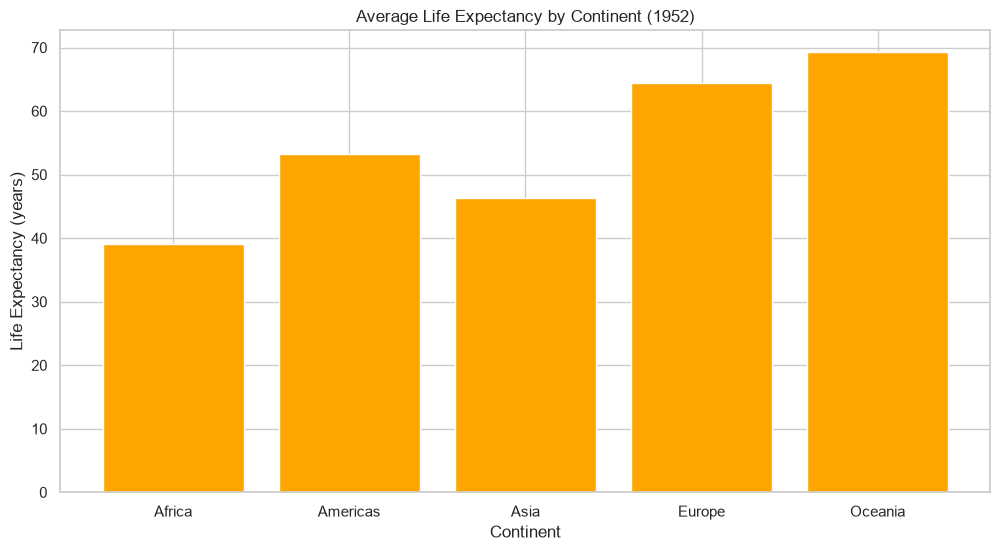

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(continent.index, continent.values, color="orange")

plt.title("Average Life Expectancy by Continent (1952)")
plt.xlabel("Continent")
plt.ylabel("Life Expectancy (years)")
plt.show()

## Task 3 — A scatter plot

Using the year **1952**, make a scatter plot of `gdpPercap` (x) vs `lifeExp` (y).
Use Seaborn and colour the dots by `continent` with `hue`.

Does the "richer = longer life" pattern hold back in 1952 too?

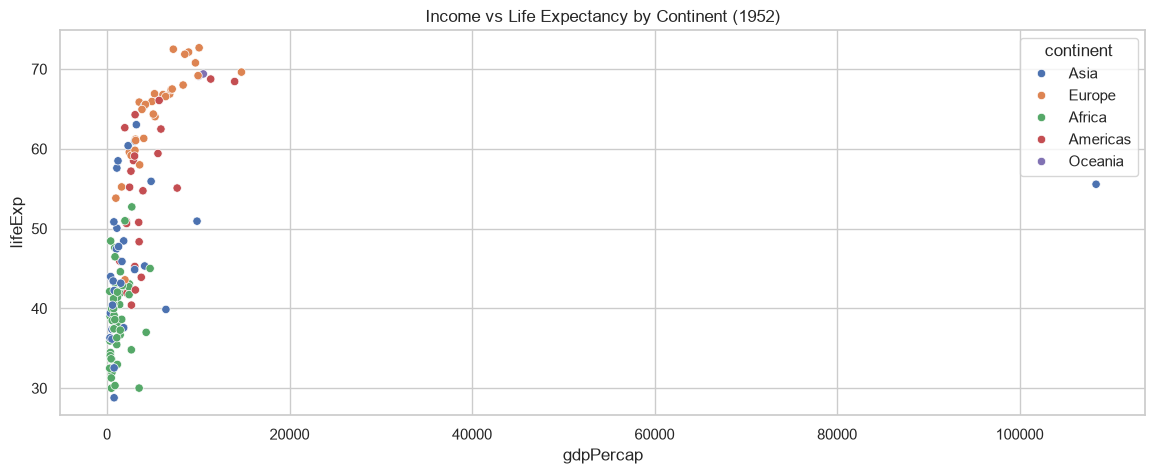

In [ ]:
# Your code here
plt.figure(figsize=(14, 5))
sns.scatterplot(data=df_1952, x="gdpPercap", y="lifeExp", hue="continent")
plt.title("Income vs Life Expectancy by Continent (1952)")
plt.show()


## Task 4 — A histogram

Make a histogram of `gdpPercap` for the year **2007** (all countries).
Use about 20 bins.

What shape do you see? Are most countries poor, rich, or in the middle?

In [29]:
df_2007 = df[df["year"] == 2007]

gdp = df_2007.groupby("country")["gdpPercap"].mean()
print(gdp.round(1))

country
Afghanistan             974.6
Albania                5937.0
Algeria                6223.4
Angola                 4797.2
Argentina             12779.4
                       ...   
Vietnam                2441.6
West Bank and Gaza     3025.3
Yemen, Rep.            2280.8
Zambia                 1271.2
Zimbabwe                469.7
Name: gdpPercap, Length: 142, dtype: float64


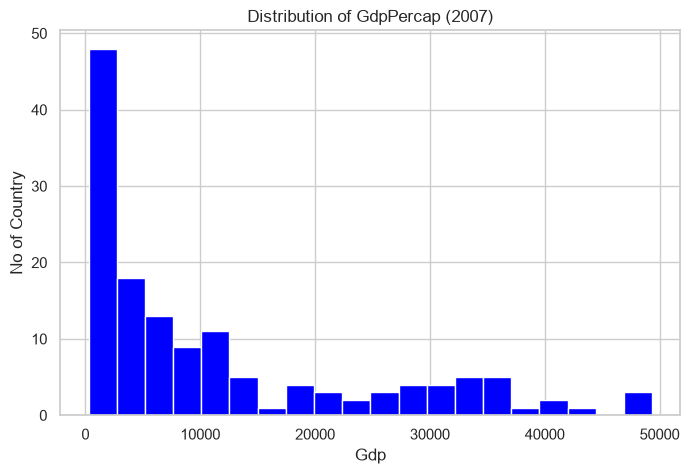

In [27]:
# Your code here
plt.figure(figsize=(8, 5))
plt.hist(df_2007["gdpPercap"], bins=20, color="blue", edgecolor="white")

plt.title("Distribution of GdpPercap (2007)")
plt.xlabel("Gdp")
plt.ylabel("No of Country")
plt.show()


## Task 5 — Compare two years on one idea

1. Make a histogram of `lifeExp` for **1952**.
2. Make a separate histogram of `lifeExp` for **2007**.

Look at both. Write a one-sentence observation as a comment in your cell:
how did the spread of life expectancy change over 55 years?

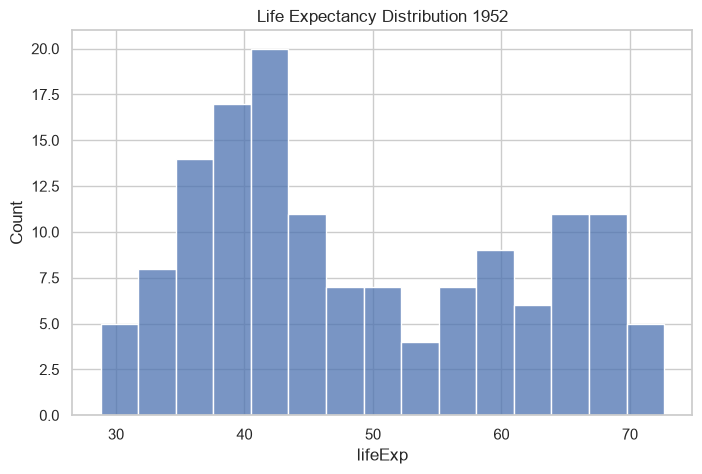

In [32]:
# Your code here
# Observation: 
plt.figure(figsize=(8, 5))
sns.histplot(data=df_1952, x="lifeExp", bins=15)
plt.title("Life Expectancy Distribution 1952")
plt.show()

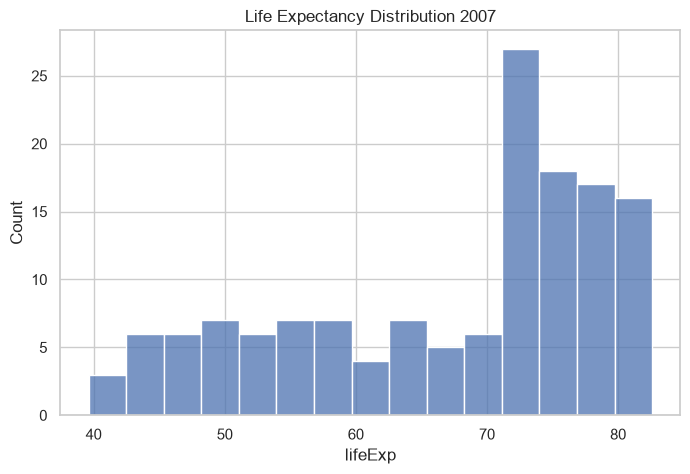

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_2007, x="lifeExp", bins=15)
plt.title("Life Expectancy Distribution 2007")
plt.show()


In [34]:
# Life expectancy has seen to increase to above 72 rather than being the highest at below 50 in 1952

## Stretch task (optional) — Colour a bar plot

Redo Task 2 (average `lifeExp` per continent in 1952) using **Seaborn's**
`sns.barplot`. Notice how much less code it takes.

Then try adding `hue="continent"` and see what happens to the legend.

<Axes: xlabel='continent', ylabel='lifeExp'>

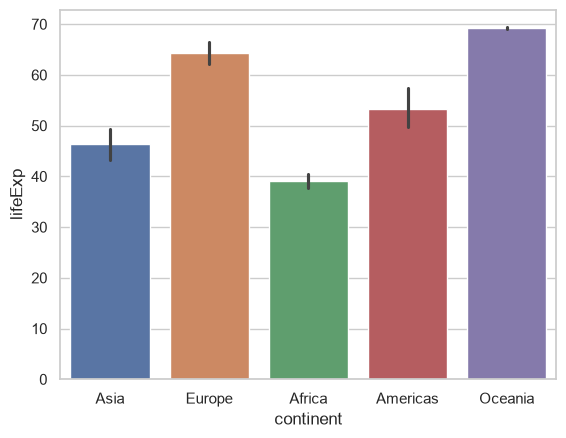

In [36]:
# Your code here
sns.barplot( data=df_1952, x="continent", y="lifeExp", hue="continent")

## Wrap-up

You practiced all four core chart types and used Seaborn's `hue` to add a third
dimension of information with one word. Tomorrow you turn these charts into a
**story** and learn to put them on a live web page with Streamlit.